# Spectral fitting example (Crab Band model with a source catalog)

This notebook fits the DC4 Crab using the latest incremental catalog written
by `Source_catalog_generator_Crab.ipynb`. Crab must be present as a fixed
single-component Band source when the catalog is loaded. The notebook frees
the Crab Band normalization, low-energy index, high-energy index, and peak
energy while every nuisance-source parameter remains fixed.

The plotted injected reference is the sum of the four actual DC4 Crab tables:
nebula, peak 1, bridge, and peak 2. Therefore the fit tests how well one Band
function approximates the true four-component injected spectrum.

In [1]:
from array import array
import gzip
from pathlib import Path
import sys

import astropy.units as u
from astropy.coordinates import SkyCoord
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

from astromodels import Band, Parameter, load_model
from histpy import Histogram
from threeML import DataList, JointLikelihood

from cosipy import BinnedData
from cosipy.background_estimation import FreeNormBinnedBackground
from cosipy.data_io import EmCDSBinnedData
from cosipy.event_selection import GoodTimeInterval
from cosipy.interfaces import ThreeMLPluginInterface
from cosipy.response import (
    BinnedInstrumentResponse,
    BinnedThreeMLModelFolding,
    BinnedThreeMLPointSourceResponse,
)
from cosipy.response.FullDetectorResponse import FullDetectorResponse
from cosipy.spacecraftfile import SpacecraftHistory
from cosipy.statistics import PoissonLikelihood
from cosipy.threeml.custom_functions import SpecFromDat  # noqa: F401

%matplotlib inline

12:32:03 WARNING   The naima package is not available. Models that depend on it will not be         ]8;id=653588;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=141495;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#43\43]8;;\
                  available                                                                                        

         WARNING   The GSL library or the pygsl wrapper cannot be loaded. Models that depend on it  ]8;id=246300;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py\functions.py]8;;\:]8;id=90799;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/functions.py#65\65]8;;\
                  will not be available.                                                                           

         WARNING   The ebltable package is not available. Models that depend on it will not be     ]8;id=25133;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py\absorption.py]8;;\:]8;id=591574;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/functions/functions_1D/absorption.py#33\33]8;;\
                  available                                                                                        

12:32:03 INFO      Starting 3ML!                                                                     ]8;id=54122;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=430962;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#44\44]8;;\

         WARNING   WARNINGs here are NOT errors                                                      ]8;id=100471;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=377428;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#45\45]8;;\

...

         WARNING   Could not import plugin FermiLATLike.py. Do you have the relative instrument     ]8;id=814708;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=364179;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#126\126]8;;\
                  software installed and configured?                                                               

12:32:04 WARNING   No fermitools installed                                              ]8;id=263350;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py\lat_transient_builder.py]8;;\:]8;id=780792;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/utils/data_builders/fermi/lat_transient_builder.py#44\44]8;;\

         WARNING   Env. variable OMP_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=482731;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=383409;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable MKL_NUM_THREADS is not set. Please set it to 1 for optimal         ]8;id=985251;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=488995;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

         WARNING   Env. variable NUMEXPR_NUM_THREADS is not set. Please set it to 1 for optimal     ]8;id=45928;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py\__init__.py]8;;\:]8;id=668872;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/__init__.py#335\335]8;;\
                  performances in 3ML                                                                              

## Load the FOV-cut data and response

The mock-data and background files below were binned after applying the same 60° NGC 4151 pointing cut used for the spacecraft history.

In [2]:
notebook_dir = Path(
    "/Users/parshadkp/Software/cosipy/docs/tutorials/spectral_fits/continuum_fit/crab"
)
mock_data_path = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/"
    "Software_Files/DC4_Files/Mock_Data/Mock_Data_Cut/"
    "dc4_mock_dataset_3months_binned_data_filtered_with_SAAcut_"
    "time_ordered_Crab_cut.hdf5"
)
background_path = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/"
    "Software_Files/DC4_Files/Background/"
    "Total_DC4_BG_3months_binned_data_filtered_with_SAAcut_withSAAbck_"
    "Crab_cut.hdf5"
)
orientation_path = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/"
    "DC4_Files/DC4_final_530km_3_month_with_slew_15sbins_GalacticEarth_SAA.ori"
)
response_path = Path(
    "/Users/parshadkp/Library/CloudStorage/OneDrive-ClemsonUniversity/COSI/Software_Files/"
    "DC4_Files/ResponseContinuum.o3.e100_10000.b10log.s10396905069491."
    "m2284.filtered.nonsparse.binnedimaging.imagingresponse.h5"
)
crab_config = notebook_dir / "crab.yaml"
source_catalog_path = notebook_dir / "source_catalog_DC4_Crab.yaml"
source_library_root = Path(
    "/Users/parshadkp/Software/cosi-sim/cosi_sim/Source_Library"
)
four_c_21p35_noflare_lc_path = (
    source_library_root
    / "DC3/sources/Extragalactic/4C21p35_noflare/4C_21_lightcurve_noflare.dat"
)
four_c_21p35_flare_lc_path = (
    source_library_root
    / "DC3/sources/Extragalactic/4C21p35_flare/4C_21_lightcurve_flare.dat"
)
maxi_j1820_lc_path = (
    source_library_root
    / "DC3/sources/Galactic/MAXIJ1820/MAXIJ1820_LC.dat"
)
maxi_j1348_lc_path = (
    source_library_root
    / "DC3/sources/Galactic/MAXIJ1348/MAXIJ1348_LC.dat"
)
three_c_454p3_low_lc_path = (
    source_library_root
    / "DC4/sources/Extragalactic/3C454p3_low/3C454p3_low_lightcurve.dat"
)
three_c_454p3_high_lc_path = (
    source_library_root
    / "DC4/sources/Extragalactic/3C454p3_high/3C454p3_high_lightcurve.dat"
)
psr_b1259_lc_path = (
    source_library_root
    / "DC3/sources/Galactic/PSRB1259/PSRB1259_lc.dat"
)
one_rxs_j170849_lc_path = (
    source_library_root
    / "DC4/sources/Galactic/1RXSJ170849/1RXSJ170849_magnetar_lightcurve.dat.gz"
)
generic_magnetar_lc_path = (
    source_library_root
    / "DC4/sources/Galactic/magnetar2/magnetar2_lightcurve.dat.gz"
)
ls_5039_lc_path = (
    source_library_root
    / "DC3/sources/Galactic/LS5039/LS5039_lc.dat"
)
psr_j1846_lc_path = (
    source_library_root
    / "DC3/sources/Galactic/PSRJ1846/J1846_lc.dat"
)
co_nova_continuum_lc_path = (
    source_library_root
    / "DC3/sources/Galactic/nova_co_continuum/nova_co_continuum_lc.dat"
)

# Eight repetitions of the three-month simulation represent 24 months.
# This scales counts and response livetime, not the intrinsic source flux.
exposure_multiplier = 8
exposure_months = 3 * exposure_multiplier

for path in (
    mock_data_path,
    background_path,
    orientation_path,
    response_path,
    crab_config,
    source_catalog_path,
    four_c_21p35_noflare_lc_path,
    four_c_21p35_flare_lc_path,
    maxi_j1820_lc_path,
    maxi_j1348_lc_path,
    three_c_454p3_low_lc_path,
    three_c_454p3_high_lc_path,
    psr_b1259_lc_path,
    one_rxs_j170849_lc_path,
    generic_magnetar_lc_path,
    ls_5039_lc_path,
    psr_j1846_lc_path,
    co_nova_continuum_lc_path,
):
    if not path.exists():
        raise FileNotFoundError(path)

Apply the 60° orientation/FOV cut for Crab, including Earth occultation.
The ordinary filtered history is used by the background, Crab, and other
steady-source responses. Variable nuisance sources receive interval-weighted
histories using their injected light curves.

In [3]:
source_l = 184.5575 * u.deg
source_b = -5.78434 * u.deg
source_coord = SkyCoord(l=source_l, b=source_b, frame="galactic")

max_offaxis = 60 * u.deg
earth_occ = True

sc_orientation_full = SpacecraftHistory.open(orientation_path)
source_gti = GoodTimeInterval.from_pointing_cut(
    source_coord,
    sc_orientation_full,
    max_offaxis,
    earth_occ=earth_occ,
)
sc_orientation_cut = sc_orientation_full.apply_gti(source_gti)

# Repeat the selected pointing history by scaling its interval livetimes.
# The attitude and Earth-occultation selection remain unchanged.
sc_orientation = SpacecraftHistory(
    sc_orientation_cut.obstime,
    sc_orientation_cut.attitude,
    sc_orientation_cut.location,
    livetime=sc_orientation_cut.livetime * exposure_multiplier,
)
sc_orientation.cache_earth_occ = sc_orientation_cut.cache_earth_occ


def load_megalib_lightcurve(lightcurve_path):
    """Read a plain or gzip-compressed MEGAlib DP light-curve table."""
    sample_times = array("d")
    relative_intensities = array("d")
    lightcurve_path = Path(lightcurve_path)
    if lightcurve_path.suffix == ".gz":
        lightcurve_file = gzip.open(lightcurve_path, "rt")
    else:
        lightcurve_file = lightcurve_path.open("rt")

    with lightcurve_file:
        for line in lightcurve_file:
            if line.startswith("DP "):
                _, sample_time, relative_intensity = line.split()
                sample_times.append(float(sample_time))
                relative_intensities.append(float(relative_intensity))

    if len(sample_times) < 2:
        raise ValueError(f"No DP samples found in {lightcurve_path}")

    return (
        np.frombuffer(sample_times, dtype=np.float64),
        np.frombuffer(relative_intensities, dtype=np.float64),
    )


def lightcurve_interval_weights(history, lightcurve_path, repeating=False):
    """Return MEGAlib-normalized mean intensity in each history interval."""
    sample_times, relative_intensity = load_megalib_lightcurve(lightcurve_path)
    if np.any(np.diff(sample_times) <= 0):
        raise ValueError(f"Light-curve times are not increasing: {lightcurve_path}")
    if np.any(relative_intensity < 0):
        raise ValueError(f"Negative light-curve value in {lightcurve_path}")

    lightcurve_duration = sample_times[-1] - sample_times[0]
    lightcurve_integral = np.trapezoid(relative_intensity, sample_times)
    if lightcurve_duration <= 0 or lightcurve_integral <= 0:
        raise ValueError(f"Invalid light-curve integral for {lightcurve_path}")

    # MCSource::UpgradeLightCurve scales every injected light curve to unit mean.
    relative_intensity = (
        relative_intensity * lightcurve_duration / lightcurve_integral
    )

    segment_widths = np.diff(sample_times)
    cumulative_integral = np.concatenate(
        (
            [0.0],
            np.cumsum(
                0.5
                * (relative_intensity[:-1] + relative_intensity[1:])
                * segment_widths
            ),
        )
    )

    def finite_antiderivative(times):
        times = np.asarray(times, dtype=float)
        clipped_times = np.clip(times, sample_times[0], sample_times[-1])
        indices = np.searchsorted(sample_times, clipped_times, side="right") - 1
        indices = np.clip(indices, 0, len(sample_times) - 2)
        offsets = clipped_times - sample_times[indices]
        slopes = (
            relative_intensity[indices + 1] - relative_intensity[indices]
        ) / segment_widths[indices]
        integrals = (
            cumulative_integral[indices]
            + relative_intensity[indices] * offsets
            + 0.5 * slopes * offsets**2
        )
        integrals = np.where(times <= sample_times[0], 0.0, integrals)
        return np.where(
            times >= sample_times[-1],
            cumulative_integral[-1],
            integrals,
        )

    interval_starts = history.intervals_tstart.unix
    interval_stops = history.intervals_tstop.unix
    interval_durations = interval_stops - interval_starts

    if repeating:
        def repeating_antiderivative(times):
            cycles = np.floor(
                (times - sample_times[0]) / lightcurve_duration
            )
            phases = sample_times[0] + np.mod(
                times - sample_times[0],
                lightcurve_duration,
            )
            return cycles * cumulative_integral[-1] + finite_antiderivative(phases)

        integrated_intensity = repeating_antiderivative(
            interval_stops
        ) - repeating_antiderivative(interval_starts)
    else:
        integrated_intensity = finite_antiderivative(
            interval_stops
        ) - finite_antiderivative(interval_starts)

    interval_weights = integrated_intensity / interval_durations
    if not np.all(np.isfinite(interval_weights)):
        raise ValueError(f"Non-finite light-curve weights for {lightcurve_path}")
    if np.any(interval_weights < -1e-12):
        raise ValueError(f"Negative interval weight for {lightcurve_path}")
    return np.clip(interval_weights, 0.0, None)


def lightcurve_weighted_history(history, lightcurve_path, repeating=False):
    """Multiply interval livetimes by interval-averaged source intensity."""
    interval_weights = lightcurve_interval_weights(
        history,
        lightcurve_path,
        repeating=repeating,
    )

    weighted_history = SpacecraftHistory(
        history.obstime,
        history.attitude,
        history.location,
        livetime=history.livetime * interval_weights * exposure_multiplier,
    )
    weighted_history.cache_earth_occ = history.cache_earth_occ
    return weighted_history


sc_orientation_4c21_noflare = lightcurve_weighted_history(
    sc_orientation_cut,
    four_c_21p35_noflare_lc_path,
)
sc_orientation_4c21_flare = lightcurve_weighted_history(
    sc_orientation_cut,
    four_c_21p35_flare_lc_path,
)
sc_orientation_maxi_j1820 = lightcurve_weighted_history(
    sc_orientation_cut,
    maxi_j1820_lc_path,
)
sc_orientation_maxi_j1348 = lightcurve_weighted_history(
    sc_orientation_cut,
    maxi_j1348_lc_path,
)
sc_orientation_3c454p3_low = lightcurve_weighted_history(
    sc_orientation_cut,
    three_c_454p3_low_lc_path,
)
sc_orientation_3c454p3_high = lightcurve_weighted_history(
    sc_orientation_cut,
    three_c_454p3_high_lc_path,
)
sc_orientation_psr_b1259 = lightcurve_weighted_history(
    sc_orientation_cut,
    psr_b1259_lc_path,
)
sc_orientation_one_rxs_j170849 = lightcurve_weighted_history(
    sc_orientation_cut,
    one_rxs_j170849_lc_path,
    repeating=True,
)
sc_orientation_generic_magnetar = lightcurve_weighted_history(
    sc_orientation_cut,
    generic_magnetar_lc_path,
    repeating=True,
)
sc_orientation_ls_5039 = lightcurve_weighted_history(
    sc_orientation_cut,
    ls_5039_lc_path,
    repeating=True,
)
sc_orientation_psr_j1846 = lightcurve_weighted_history(
    sc_orientation_cut,
    psr_j1846_lc_path,
    repeating=True,
)
sc_orientation_co_nova_continuum = lightcurve_weighted_history(
    sc_orientation_cut,
    co_nova_continuum_lc_path,
)

full_livetime = sc_orientation_full.cumulative_livetime().to_value(u.s)
fov_livetime = sc_orientation_cut.cumulative_livetime().to_value(u.s)
scaled_livetime = sc_orientation.cumulative_livetime().to_value(u.s)
print(f"Full orientation livetime: {full_livetime:,.1f} s")
print(f"Three-month FOV-cut livetime: {fov_livetime:,.1f} s")
print(f"Scaled {exposure_months}-month livetime: {scaled_livetime:,.1f} s")
print(f"FOV/full livetime fraction: {fov_livetime / full_livetime:.4f}")
for label, weighted_history in (
    ("4C 21.35 non-flare", sc_orientation_4c21_noflare),
    ("4C 21.35 flare", sc_orientation_4c21_flare),
    ("MAXI J1820", sc_orientation_maxi_j1820),
    ("MAXI J1348", sc_orientation_maxi_j1348),
    ("3C 454.3 low", sc_orientation_3c454p3_low),
    ("3C 454.3 high", sc_orientation_3c454p3_high),
    ("PSR B1259−63", sc_orientation_psr_b1259),
    ("1RXS J170849", sc_orientation_one_rxs_j170849),
    ("Generic magnetar", sc_orientation_generic_magnetar),
    ("LS 5039", sc_orientation_ls_5039),
    ("PSR J1846−0258", sc_orientation_psr_j1846),
    ("CO nova continuum", sc_orientation_co_nova_continuum),
):
    print(
        f"{label} light-curve-weighted livetime:",
        weighted_history.cumulative_livetime(),
    )

Full orientation livetime: 6,579,555.0 s
Three-month FOV-cut livetime: 2,376,540.0 s
Scaled 24-month livetime: 19,012,320.0 s
FOV/full livetime fraction: 0.3612
4C 21.35 non-flare light-curve-weighted livetime: 19002671.802503232 s
4C 21.35 flare light-curve-weighted livetime: 19014917.277940996 s
MAXI J1820 light-curve-weighted livetime: 19004419.63215242 s
MAXI J1348 light-curve-weighted livetime: 19053170.499140806 s
3C 454.3 low light-curve-weighted livetime: 18990315.91570288 s
3C 454.3 high light-curve-weighted livetime: 19053322.02857092 s
PSR B1259−63 light-curve-weighted livetime: 18972038.597282823 s
1RXS J170849 light-curve-weighted livetime: 19012292.765062332 s
Generic magnetar light-curve-weighted livetime: 19012303.01998329 s
LS 5039 light-curve-weighted livetime: 18944638.647109985 s
PSR J1846−0258 light-curve-weighted livetime: 19012319.918426514 s
CO nova continuum light-curve-weighted livetime: 12358067.469496764 s


Load the Crab-FOV mock data and matching total-background template.
`exposure_multiplier` scales the three-month source and background counts to
24 months. It does not change any intrinsic source-spectrum parameters.

In [4]:
mock_data = BinnedData(crab_config)
mock_data.load_binned_data_from_hdf5(binned_data=mock_data_path)

data_hist = mock_data.binned_data.project("Em", "Phi", "PsiChi")
data_hist *= exposure_multiplier

total_bkg = Histogram.open(background_path).project("Em", "Phi", "PsiChi")
total_bkg *= exposure_multiplier
total_bkg += sys.float_info.min
bkg_dist = {"total_bkg": total_bkg}

Open the continuum response.

In [5]:
dr = FullDetectorResponse.open(str(response_path))

## Perform the spectral fit

Load the current fixed catalog before constructing the COSI response.
Variable nuisance sources receive their MEGAlib-normalized,
light-curve-weighted responses only when present.

The fitted Crab catalog entry is a single unpolarized Band component. The
injected DC4 source was polarized, but the available continuum response has no
`Pol` axis. Exact polarized folding would require a polarization-capable
response.

In [6]:
# Load the latest incremental catalog before constructing source responses.
model = load_model(source_catalog_path)
assert len(model.free_parameters) == 0
if "crab" not in model.sources:
    raise RuntimeError("The incremental catalog must always contain crab")

crab_polarization_supported = "Pol" in dr.axes.labels
if not crab_polarization_supported:
    print(
        "WARNING: The detector response has no Pol axis. "
        "The single Crab Band fit is unpolarized."
    )

data = EmCDSBinnedData(data_hist)

bkg = FreeNormBinnedBackground(
    bkg_dist,
    sc_history=sc_orientation,
    copy=False,
)

instrument_response = BinnedInstrumentResponse(dr, data)


def make_point_source_response(spacecraft_history):
    return BinnedThreeMLPointSourceResponse(
        data=data,
        instrument_response=instrument_response,
        sc_history=spacecraft_history,
        energy_axis=dr.axes["Ei"],
        polarization_axis=(
            dr.axes["Pol"] if "Pol" in dr.axes.labels else None
        ),
        nside=2 * data.axes["PsiChi"].nside,
    )


psr = make_point_source_response(sc_orientation)
time_dependent_histories = {
    "four_c_21p35_noflare": sc_orientation_4c21_noflare,
    "four_c_21p35_flare": sc_orientation_4c21_flare,
    "maxi_j1820": sc_orientation_maxi_j1820,
    "maxi_j1348": sc_orientation_maxi_j1348,
    "three_c_454p3_low": sc_orientation_3c454p3_low,
    "three_c_454p3_high": sc_orientation_3c454p3_high,
    "psr_b1259": sc_orientation_psr_b1259,
    "one_rxs_j170849": sc_orientation_one_rxs_j170849,
    "generic_magnetar": sc_orientation_generic_magnetar,
    "ls_5039": sc_orientation_ls_5039,
    "psr_j1846": sc_orientation_psr_j1846,
    "co_nova_continuum": sc_orientation_co_nova_continuum,
}
source_specific_psr = {
    source_name: make_point_source_response(time_dependent_histories[source_name])
    for source_name in model.sources
    if source_name in time_dependent_histories
}
expected_variable_sources = set(model.sources) & set(time_dependent_histories)
assert set(source_specific_psr) == expected_variable_sources

response = BinnedThreeMLModelFolding(
    data=data,
    point_source_response=psr,
    source_specific_point_source_responses=source_specific_psr,
)
like_fun = PoissonLikelihood(data, response, bkg)
cosi = ThreeMLPluginInterface("cosi", like_fun, response, bkg)

for bkg_label in bkg_dist:
    cosi.bkg_parameter[bkg_label] = Parameter(
        bkg_label,
        1.0,
        min_value=0.0,
        max_value=50.0,
        delta=0.05,
        unit=u.Hz,
    )

print(f"Loaded catalog with {len(model.sources)} entries:")
for source_name in model.sources:
    if source_name == "crab":
        response_kind = "single unpolarized Band"
    elif source_name in source_specific_psr:
        response_kind = "light-curve weighted"
    else:
        response_kind = "steady"
    print(f"  {source_name}: {response_kind} response")


12:32:52 WARNING   The current value of the parameter beta (-2.0) was above the new maximum -2.15. ]8;id=408753;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=831011;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

Loaded catalog with 21 entries:
  crab: single unpolarized Band response
  maxi_j1820: light-curve weighted response
  maxi_j1348: light-curve weighted response
  cyg_x1_hard: steady response
  four_c_21p35_flare: light-curve weighted response
  one_e_1740_compow: steady response
  grs_1758_258: steady response
  ngc4151: steady response
  cena: steady response
  ngc1068: steady response
  cyg_x3: steady response
  four_c_71p07: steady response
  four_c_21p35_noflare: light-curve weighted response
  psr_b1259: light-curve weighted response
  generic_magnetar: light-curve weighted response
  one_rxs_j170849: light-curve weighted response
  ls_5039: light-curve weighted response
  three_c_454p3_low: light-curve weighted response
  three_c_454p3_high: light-curve weighted response
  psr_j1846: light-curve weighted response
  co_nova_continuum: light-curve weighted response


The catalog starts completely fixed. Free the four Crab Band fit
parameters—`K`, `alpha`, `beta`, and `xp`—while keeping the 500 keV
pivot and all nuisance-source parameters fixed. The injected comparison
spectrum is constructed independently from the four DC4 tables.

In [7]:
def normalized_table_spectrum(dat_path, injected_photon_flux):
    """Load one injected table and normalize it over 100 keV–10 MeV."""
    spectrum = SpecFromDat(
        K=float(injected_photon_flux),
        dat=Path(dat_path).resolve(),
    )
    integration_energy = np.geomspace(100.0, 10_000.0, 20_000)
    current_integral = np.trapezoid(
        spectrum(integration_energy),
        integration_energy,
    )
    spectrum.K.value *= float(injected_photon_flux) / current_integral
    return spectrum


crab_table_root = (
    source_library_root / "DC4/sources/Galactic/Crab"
)
injected_components = (
    normalized_table_spectrum(
        crab_table_root / "Crab_Ne_spec.dat",
        0.033197515,
    ),
    normalized_table_spectrum(
        crab_table_root / "Crab_P1_spec.dat",
        0.002380673782066656,
    ),
    normalized_table_spectrum(
        crab_table_root / "Crab_Brg_spec.dat",
        0.0006280494007254569,
    ),
    normalized_table_spectrum(
        crab_table_root / "Crab_P2_spec.dat",
        0.0032012384701172636,
    ),
)
injected_crab_spectrum = sum(injected_components[1:], injected_components[0])

energy = np.geomspace(100 * u.keV, 10 * u.MeV, 200).to_value(u.keV)
flux_inj = np.asarray(injected_crab_spectrum(energy), dtype=float)

assert len(model.free_parameters) == 0

crab_band = model.crab.spectrum.main.Band
crab_band.K.min_value = 1e-8
crab_band.K.max_value = 1e-2
crab_band.K.delta = 0.05 * crab_band.K.value
crab_band.K.fix = False

crab_band.alpha.min_value = -2.14
crab_band.alpha.max_value = 3.0
crab_band.alpha.delta = 0.01
crab_band.alpha.fix = False

crab_band.beta.min_value = -5.0
crab_band.beta.max_value = -2.15
crab_band.beta.delta = 0.01
crab_band.beta.fix = False

crab_band.xp.min_value = 1.0
crab_band.xp.max_value = 10_000.0
crab_band.xp.delta = 0.05 * crab_band.xp.value
crab_band.xp.fix = False

expected_free_parameters = {
    "crab.spectrum.main.Band.K",
    "crab.spectrum.main.Band.alpha",
    "crab.spectrum.main.Band.beta",
    "crab.spectrum.main.Band.xp",
}
assert set(model.free_parameters) == expected_free_parameters
assert crab_band.piv.fix
assert all(path.startswith("crab.") for path in model.free_parameters)

print("Model sources:", list(model.sources))
print("Free parameters:", list(model.free_parameters))
print(crab_band.xp.value)


Model sources: ['crab', 'maxi_j1820', 'maxi_j1348', 'cyg_x1_hard', 'four_c_21p35_flare', 'one_e_1740_compow', 'grs_1758_258', 'ngc4151', 'cena', 'ngc1068', 'cyg_x3', 'four_c_71p07', 'four_c_21p35_noflare', 'psr_b1259', 'generic_magnetar', 'one_rxs_j170849', 'ls_5039', 'three_c_454p3_low', 'three_c_454p3_high', 'psr_j1846', 'co_nova_continuum']
Free parameters: ['crab.spectrum.main.Band.K', 'crab.spectrum.main.Band.alpha', 'crab.spectrum.main.Band.xp', 'crab.spectrum.main.Band.beta']
5.310000000000005


Fit the source model and background normalization once.

In [8]:
plugins = DataList(cosi)
like = JointLikelihood(model, plugins, verbose=False)
_ = like.fit()

12:32:52 INFO      set the minimizer to minuit                                             ]8;id=584980;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=391496;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/threeML/classicMLE/joint_likelihood.py#1017\1017]8;;\


WARNING IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.


WARNING IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.


WARNING IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the in

12:34:24 WARNING   The current value of the parameter beta (-2.0) was above the new maximum -2.15. ]8;id=635893;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=229667;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

Best fit values:

,result,unit
parameter,,
crab.spectrum.main.Band.K,(2.67 +/- 0.04) x 10^-5,1 / (keV s cm2)
crab.spectrum.main.Band.alpha,-1.720 +/- 0.009,
crab.spectrum.main.Band.xp,(2.536 -0.017 +0.018) x 10^2,keV
crab.spectrum.main.Band.beta,-2.1953 +/- 0.0030,
total_bkg,(2.46533 +/- 0.00018) x 10,Hz


...

1.00,0.99,0.13,0.19,0.07
0.99,1.00,0.26,0.12,0.13
0.13,0.26,1.00,-0.51,0.19
0.19,0.12,-0.51,1.00,-0.28
0.07,0.13,0.19,-0.28,1.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
cosi,-3799255729.6341643
total,-3799255729.6341643


Values of statistical measures:

,statistical measures
AIC,-7598511449.268068
BIC,-7598511397.530468


## Error propagation and plotting

Propagate the joint uncertainty in the four free Band parameters to the
fitted Crab spectrum.

In [9]:
results = like.results
print(results.display())

optimized_crab = results.optimized_model.crab
parameters = {
    parameter.name: results.get_variates(parameter.path)
    for parameter in optimized_crab.parameters.values()
    if parameter.free
}
results_err = results.propagate(
    optimized_crab.spectrum.main.shape.evaluate_at,
    **parameters,
)

print(optimized_crab)


Best fit values:

,result,unit
parameter,,
crab.spectrum.main.Band.K,(2.67 +/- 0.04) x 10^-5,1 / (keV s cm2)
crab.spectrum.main.Band.alpha,-1.720 +/- 0.009,
crab.spectrum.main.Band.xp,(2.536 -0.017 +0.018) x 10^2,keV
crab.spectrum.main.Band.beta,-2.1953 +/- 0.0030,
total_bkg,(2.46533 +/- 0.00018) x 10,Hz


Correlation matrix:

1.00,0.99,0.13,0.19,0.07
0.99,1.00,0.26,0.12,0.13
0.13,0.26,1.00,-0.51,0.19
0.19,0.12,-0.51,1.00,-0.28
0.07,0.13,0.19,-0.28,1.00


Values of -log(likelihood) at the minimum:

...

Values of statistical measures:

,statistical measures
AIC,-7598511449.268068
BIC,-7598511397.530468


None


12:34:25 WARNING   The current value of the parameter beta (-2.0) was above the new maximum -2.15. ]8;id=705537;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=924453;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

  * crab (point source):
    * position:
      * l:
        * value: 184.5575
        * desc: Galactic longitude
        * min_value: 0.0
        * max_value: 360.0
        * unit: deg
        * is_normalization: false
      * b:
        * value: -5.78434
        * desc: Galactic latitude
        * min_value: -90.0
        * max_value: 90.0
        * unit: deg
        * is_normalization: false
      * equinox: J2000
    * spectrum:
      * main:
        * Band:
          * K:
            * value: 2.6705775557450512e-05
            * desc: Differential flux at the pivot energy
            * min_value: 1.0e-08
            * max_value: 0.01
            * unit: keV-1 s-1 cm-2
            * is_normalization: true
          * alpha:
            * value: -1.7195195999064585
            * desc: low-energy photon index
            * min_value: -2.14
            * max_value: 3.0
            * unit: ''
            * is_normalization: false
          * xp:
            * value: 253.6239712573931
  

Evaluate the fitted Band spectrum and the true summed four-table injected
spectrum from 100 keV to 10 MeV.

In [10]:
flux_lo = np.zeros_like(energy)
flux_median = np.zeros_like(energy)
flux_hi = np.zeros_like(energy)

for i, e in enumerate(energy):
    flux = results_err(e)
    flux_median[i] = flux.median
    flux_lo[i], flux_hi[i] = flux.equal_tail_interval(cl=0.68)

binned_energy_edges = data_hist.axes["Em"].edges.to_value(u.keV)
binned_energy = 0.5 * (binned_energy_edges[1:] + binned_energy_edges[:-1])
expectation = response.expectation()


Plot the fitted Band SED and the summed four-component injected SED.

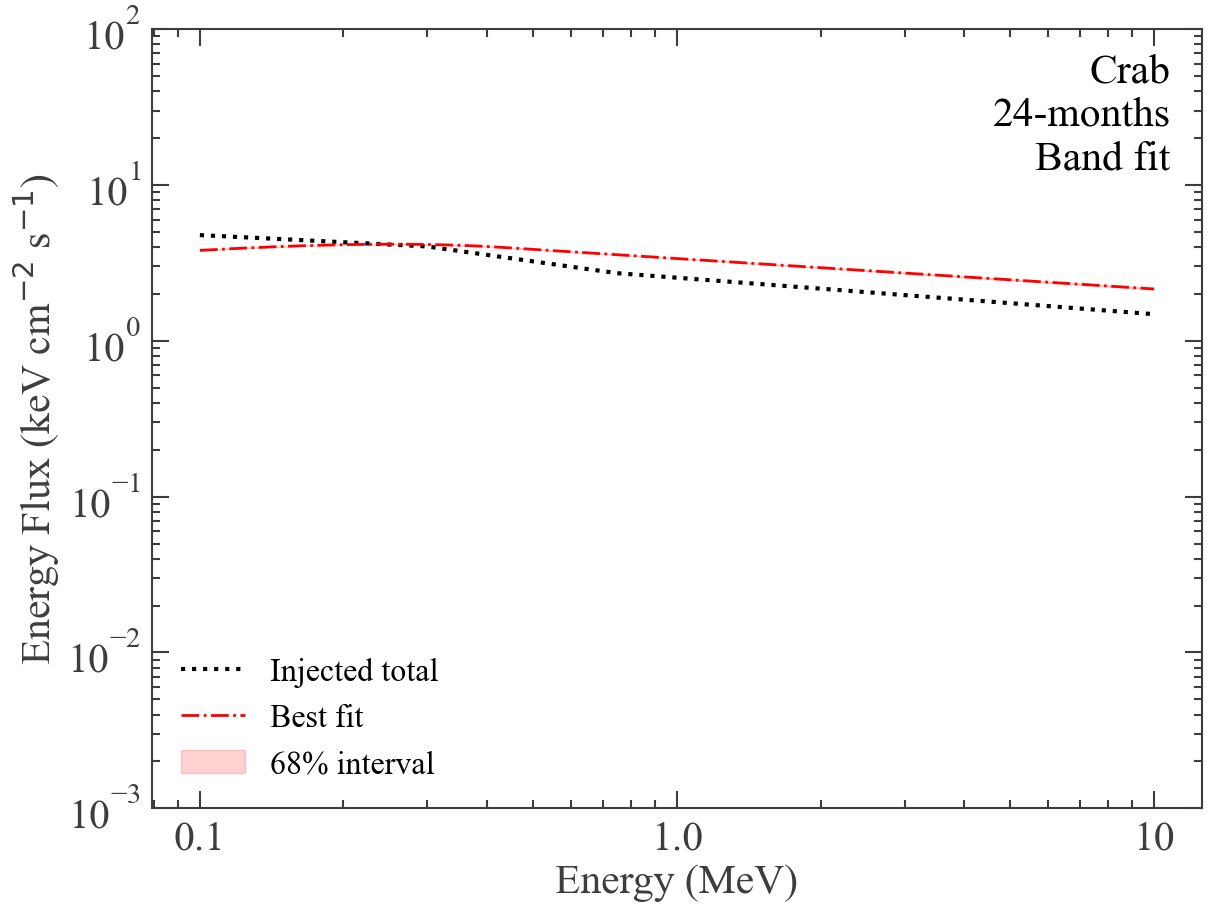

In [11]:
FONT_SIZE = 30
plt.rcParams["agg.path.chunksize"] = 10000
plt.rcParams.update({"font.size": FONT_SIZE})
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["axes.linewidth"] = 1.5
plt.rcParams.update({
    "font.weight": "550",
    "axes.titleweight": "550",
    "axes.labelweight": "550",
})


def style_axis(ax):
    ax.xaxis.set_tick_params(which="major", size=12, width=1.5, direction="in", top=True, pad=8, labelsize=FONT_SIZE)
    ax.xaxis.set_tick_params(which="minor", size=6, width=1.5, direction="in", top=True, pad=8)
    ax.yaxis.set_tick_params(which="major", size=12, width=1.5, direction="in", right=True, pad=8, labelsize=FONT_SIZE)
    ax.yaxis.set_tick_params(which="minor", size=6, width=1.5, direction="in", right=True, pad=8)
    ax.spines["right"].set_visible(True)
    ax.spines["top"].set_visible(True)


fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)
style_axis(ax)

ax.plot(
    energy / 1000,
    energy * energy * flux_inj,
    color="black",
    ls=":",
    lw=3,
    label="Injected total",
)
ax.plot(
    energy / 1000,
    energy * energy * flux_median,
    color="red",
    lw=2,
    linestyle="dashdot",
    label="Best fit",
)
ax.fill_between(
    energy / 1000,
    energy * energy * flux_lo,
    energy * energy * flux_hi,
    alpha=0.18,
    color="red",
    label="68% interval",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(1e-3, 100)
ax.xaxis.set_major_locator(mticker.FixedLocator([0.1, 1.0, 10.0]))
ax.xaxis.set_major_formatter(mticker.FixedFormatter(["0.1", "1.0", "10"]))
ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.set_ylabel(r"Energy Flux (keV cm$^{-2}$ s$^{-1}$)", fontsize=FONT_SIZE)
ax.text(
    0.97,
    0.97,
    f"Crab\n{exposure_months}-months\nBand fit",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=FONT_SIZE,
    fontweight="550",
)
ax.legend(fontsize=23, loc="lower left", frameon=False)
plt.show()


Compare the fitted Band spectrum with the analytic injected Band model used in the original `SpectralFit_Crab_DC4.ipynb`. This is a second reference comparison; the preceding plot retains the exact summed four-table DC4 injection.


12:34:44 WARNING   The current value of the parameter beta (-2.0) was above the new maximum -2.15. ]8;id=817697;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=399920;file:///Users/parshadkp/.pyenv/versions/cosipy312/lib/python3.12/site-packages/astromodels/core/parameter.py#810\810]8;;\

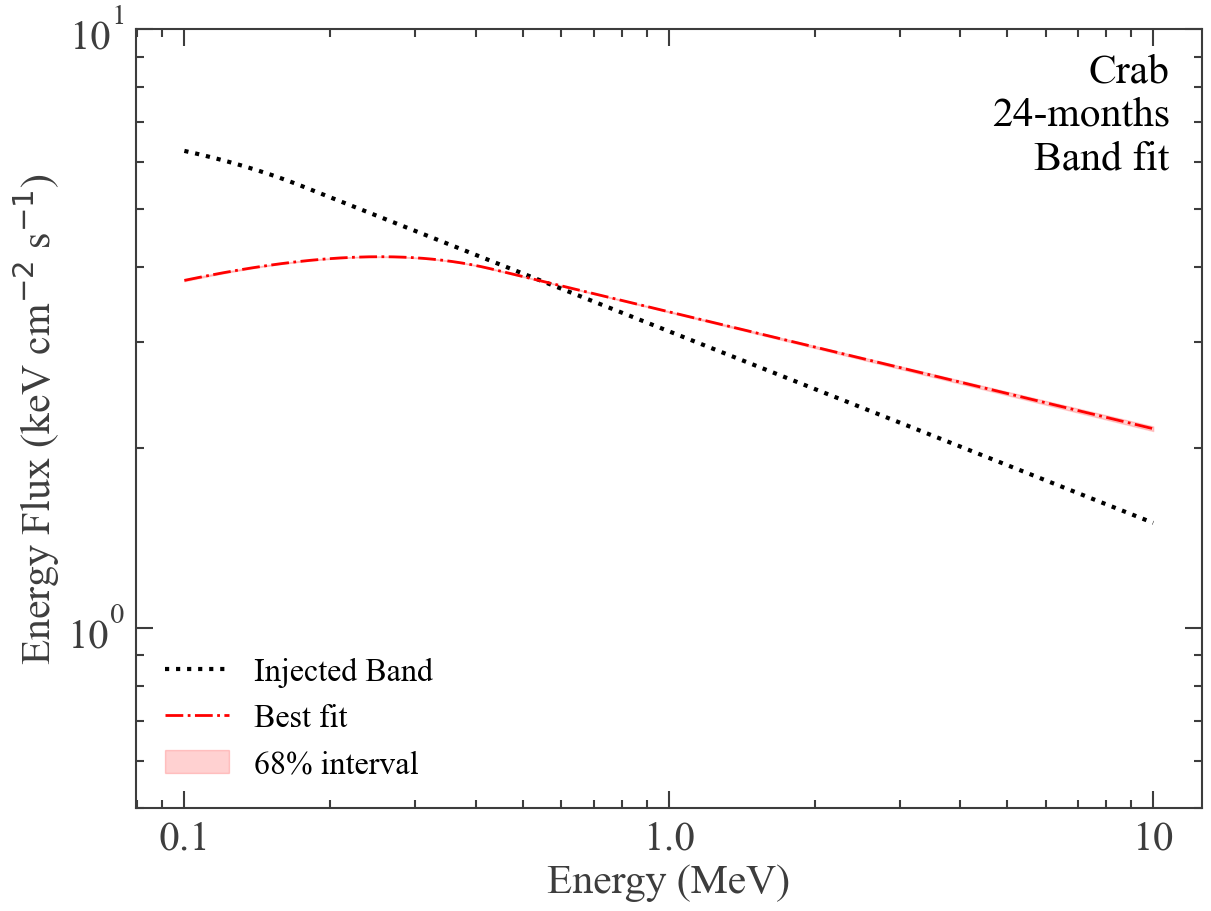

In [12]:
crab_injected_band = Band()
crab_injected_band.alpha.min_value = -2.14
crab_injected_band.alpha.max_value = 3.0
crab_injected_band.beta.min_value = -5.0
crab_injected_band.beta.max_value = -2.15
crab_injected_band.xp.min_value = 1.0

crab_injected_band.alpha.value = -1.99
crab_injected_band.beta.value = -2.32
crab_injected_band.xp.value = 5.31
crab_injected_band.K.value = 7.56e-4
crab_injected_band.piv.value = 100.0

crab_injected_band.xp.unit = u.keV
crab_injected_band.K.unit = 1 / (u.keV * u.s * u.cm**2)
crab_injected_band.piv.unit = u.keV

flux_injected_band = np.asarray(
    crab_injected_band.evaluate_at(energy),
    dtype=float,
)

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)
style_axis(ax)

ax.plot(
    energy / 1000,
    energy * energy * flux_injected_band,
    color="black",
    ls=":",
    lw=3,
    label="Injected Band",
)
ax.plot(
    energy / 1000,
    energy * energy * flux_median,
    color="red",
    lw=2,
    linestyle="dashdot",
    label="Best fit",
)
ax.fill_between(
    energy / 1000,
    energy * energy * flux_lo,
    energy * energy * flux_hi,
    alpha=0.18,
    color="red",
    label="68% interval",
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(5e-1, 10)
ax.xaxis.set_major_locator(mticker.FixedLocator([0.1, 1.0, 10.0]))
ax.xaxis.set_major_formatter(mticker.FixedFormatter(["0.1", "1.0", "10"]))
ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.set_ylabel(
    r"Energy Flux (keV cm$^{-2}$ s$^{-1}$)",
    fontsize=FONT_SIZE,
)
ax.text(
    0.97,
    0.97,
    f"Crab\n{exposure_months}-months\nBand fit",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=FONT_SIZE,
    fontweight="550",
)
ax.legend(fontsize=23, loc="lower left", frameon=False)
plt.show()


Plot the complete fitted source catalog plus background and compare it with
the observed Crab-FOV counts.

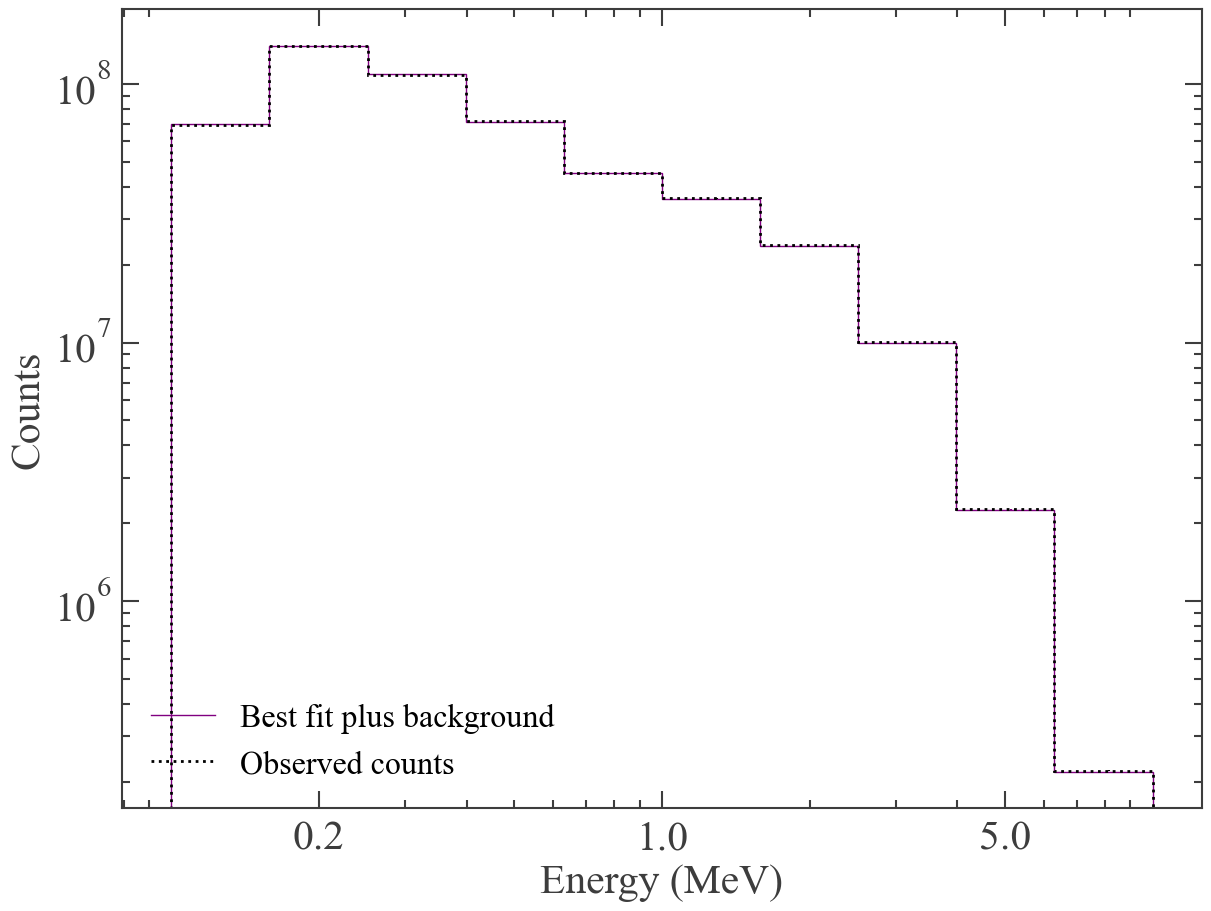

In [13]:
expectation_bkg = bkg.expectation(copy=True)
model_counts = (
    expectation.project("Em").to_dense(copy=False).contents
    + expectation_bkg.project("Em").to_dense(copy=False).contents
)
data_counts = data.data.project("Em").to_dense(copy=False).contents

fig, ax = plt.subplots(figsize=(12, 9), constrained_layout=True)
style_axis(ax)

ax.stairs(
    model_counts,
    binned_energy_edges / 1000,
    color="purple",
    label="Best fit plus background",
)
ax.errorbar(
    binned_energy / 1000,
    model_counts,
    yerr=np.sqrt(model_counts),
    color="purple",
    linewidth=0,
    elinewidth=1.5,
)
ax.stairs(
    data_counts,
    binned_energy_edges / 1000,
    color="black",
    ls=":",
    lw=2,
    label="Observed counts",
)
ax.errorbar(
    binned_energy / 1000,
    data_counts,
    yerr=np.sqrt(data_counts),
    color="black",
    linewidth=0,
    elinewidth=1.5,
)

ax.set_xscale("log")
ax.set_yscale("log")
ax.xaxis.set_major_locator(mticker.FixedLocator([0.2, 1.0, 5.0]))
ax.xaxis.set_major_formatter(mticker.FixedFormatter(["0.2", "1.0", "5.0"]))
ax.set_xlabel("Energy (MeV)", fontsize=FONT_SIZE)
ax.set_ylabel("Counts", fontsize=FONT_SIZE)
ax.legend(fontsize=23, loc="lower left", frameon=False)
plt.show()